<div style="background: linear-gradient(135deg, #6a0dad 0%, #1a759f 50%, #52b788 100%); padding: 35px 30px; border-radius: 12px; margin-bottom: 20px;">
  <h1 style="color: white; font-family: 'Segoe UI', sans-serif; font-size: 2.2em; margin: 0; font-weight: 700;">⚙️ Ingeniería de Features</h1>
  <p style="color: #e2e2ff; font-size: 1.1em; margin: 12px 0 0;">E-Commerce Churn Prediction &nbsp;|&nbsp; No Country — Equipo 40</p>
</div>

> **Objetivo:** Construir el conjunto completo de variables para el modelo predictivo.  
> **Principio:** Ir más allá del RFM básico — agregar contexto de comportamiento del cliente.  
> **Output:** `data/processed/rfm_with_churn.parquet` enriquecido + `models/champion/scaler.pkl`

---

## 📋 Tabla de Contenidos

| # | Sección | Técnica |
|---|---------|--------|
| 1 | [⚙️ Configuración](#1) | Setup del entorno |
| 2 | [📥 Carga de Datos](#2) | Transacciones limpias + RFM etiquetado |
| 3 | [🧠 Features Avanzadas](#3) | AvgTicket, DaysBetween, StdDev, Unique, PeakHour |
| 4 | [📊 Correlación con Churn](#4) | ¿Cuánto predice cada feature? |
| 5 | [🔥 Matriz de Correlación](#5) | Detectar multicolinealidad |
| 6 | [⚖️ Escalamiento](#6) | StandardScaler + serialización del scaler |
| 7 | [✅ Conclusiones](#7) | Dataset final listo para modelado |

---
## ⚙️ 1. Configuración <a id='1'></a>

In [1]:
import sys, os
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'primary':'#2d6a4f','secondary':'#52b788','accent':'#1a759f','warning':'#e76f51','danger':'#d62828'}

with open('config/config.yaml') as f:
    cfg = yaml.safe_load(f)

Path('reports/figures/eda').mkdir(parents=True, exist_ok=True)
print('✅ Entorno configurado')

✅ Entorno configurado


---
## 📥 2. Carga de Datos <a id='2'></a>

> Se cargan dos fuentes:
> - **`rfm_with_churn.parquet`** — métricas RFM con etiqueta de churn (del notebook 02)
> - **`cleaned_transactions.parquet`** — transacciones limpias para calcular las features avanzadas

In [2]:
# Cargar RFM etiquetado
rfm_churn = pd.read_parquet('data/processed/rfm_with_churn.parquet')

# Cargar o reconstruir transacciones limpias
interim_path = Path('data/interim/cleaned_transactions.parquet')
if not interim_path.exists():
    print('⚠️  Reconstruyendo transacciones limpias...')
    from src.data.loader import DataLoader
    from src.features.preprocessing import TransactionPreprocessor
    loader = DataLoader(cfg['paths']['raw_data'])
    df_raw = loader.load()
    pre = TransactionPreprocessor()
    clean_df = pre.fit_transform(df_raw)
    interim_path.parent.mkdir(parents=True, exist_ok=True)
    clean_df.to_parquet(interim_path, index=False)
else:
    clean_df = pd.read_parquet(interim_path)

print(f'✅ Transacciones limpias : {len(clean_df):>10,} filas')
print(f'✅ RFM con churn         : {len(rfm_churn):>10,} clientes')
print(f'   → Ratio: {len(clean_df)/len(rfm_churn):.1f} transacciones/cliente en promedio')

✅ Transacciones limpias :    805,531 filas
✅ RFM con churn         :      5,878 clientes
   → Ratio: 137.0 transacciones/cliente en promedio


---
## 🧠 3. Construcción de Features Avanzadas <a id='3'></a>

> **¿Por qué más allá de RFM?**  
> Las métricas RFM capturan el *qué*, pero no el *cómo* compra un cliente.  
> Las features avanzadas añaden **contexto comportamental** que mejora la capacidad discriminativa del modelo.

| Feature | Fórmula | Intuición de negocio |
|---------|---------|---------------------|
| `AvgTicket` | `mean(TotalSum por Invoice)` | Mayor ticket → mayor engagement |
| `DaysBetweenPurchases` | `mean(diff entre fechas)` | Ciclo de compra habitual |
| `MonetaryStdDev` | `std(TotalSum por Invoice)` | Consistencia del gasto |
| `UniqueProducts` | `nunique(StockCode)` | Amplitud de intereses |
| `PeakHourBuyer` | `mean(compras entre 10-14h)` | Patrón de horario habitual |

In [3]:
from src.features.advanced_features import AdvancedFeatureEngineer

peak_hours = tuple(cfg.get('features', {}).get('peak_hours', [10, 14]))
fe = AdvancedFeatureEngineer(peak_hours=peak_hours)
rfm_enriched = fe.build(clean_df, rfm_churn)

advanced_cols = ['AvgTicket', 'DaysBetweenPurchases', 'MonetaryStdDev', 'UniqueProducts', 'PeakHourBuyer']
available_adv = [c for c in advanced_cols if c in rfm_enriched.columns]

print(f'✅ Features avanzadas generadas: {len(available_adv)}')
print(f'   Columnas: {available_adv}')
print(f'   Shape final: {rfm_enriched.shape}')
print()
rfm_enriched[available_adv].describe().round(2)

✅ Features avanzadas generadas: 5
   Columnas: ['AvgTicket', 'DaysBetweenPurchases', 'MonetaryStdDev', 'UniqueProducts', 'PeakHourBuyer']
   Shape final: (5878, 10)



,AvgTicket,DaysBetweenPurchases,MonetaryStdDev,UniqueProducts,PeakHourBuyer
count,5878.00,5878.00,5878.00,5878.00,5878.00
mean,391.73,12.75,182.95,81.99,0.54
std,1215.07,64.19,1640.00,116.48,0.37
min,2.95,0.00,0.00,1.00,0.00
25%,181.65,0.00,0.00,19.00,0.21
50%,285.07,1.94,86.08,45.00,0.56
75%,420.57,5.03,184.62,103.00,0.96
max,84236.25,739.00,119123.95,2550.00,1.00


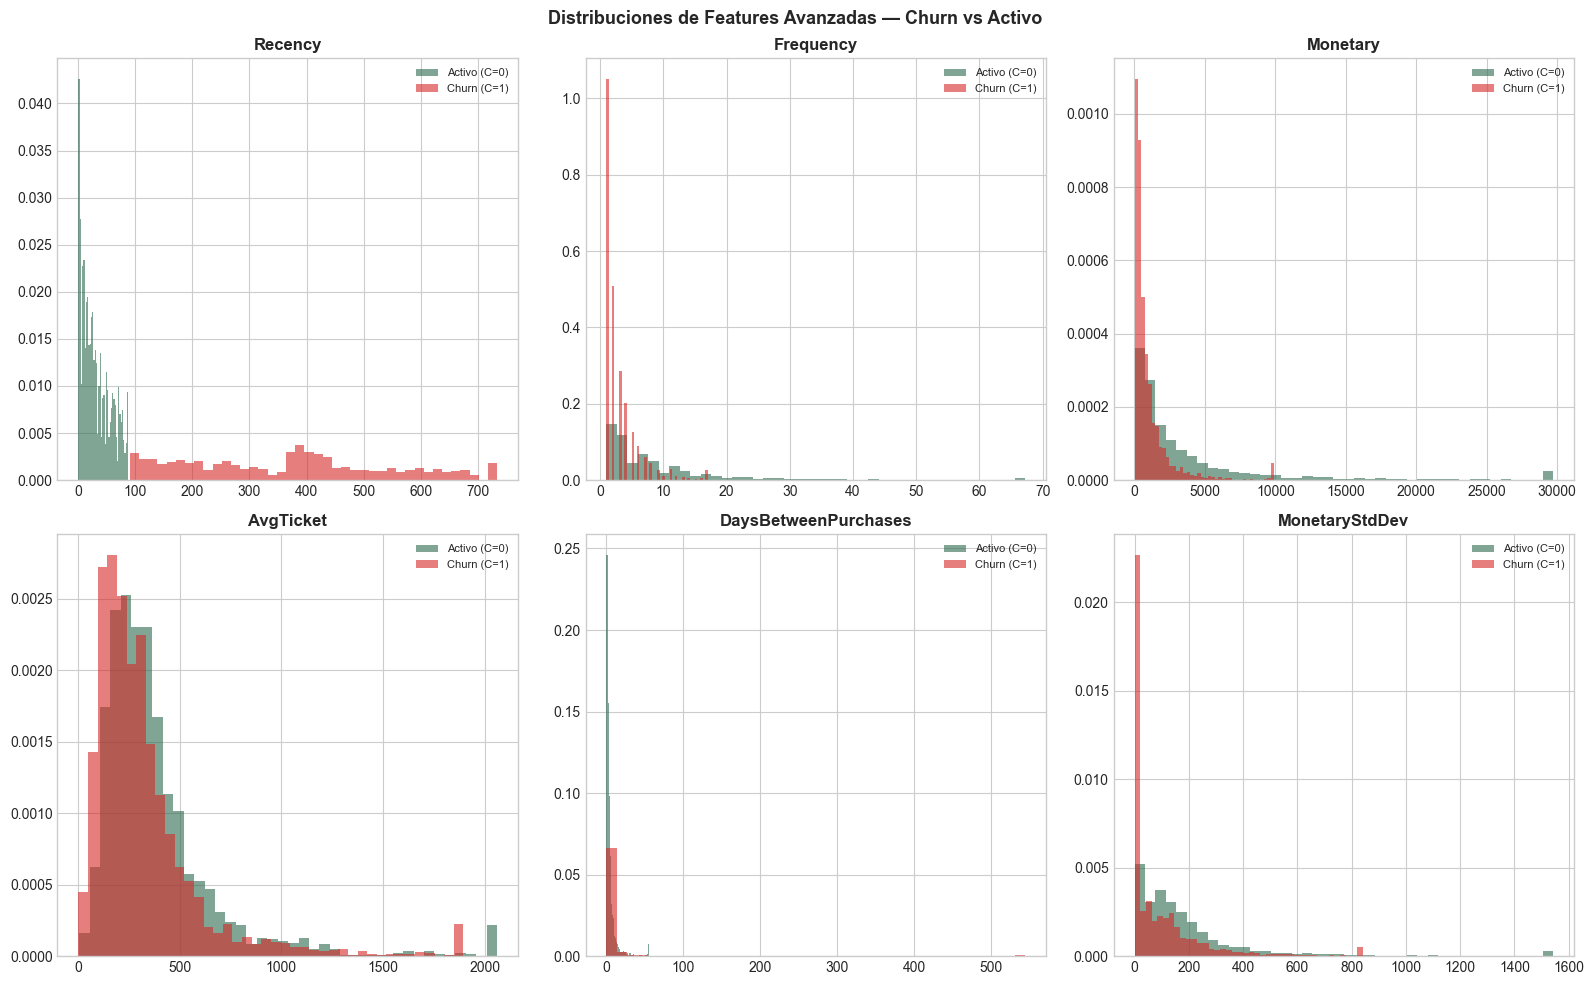

✅ Guardado: reports/figures/eda/advanced_features_distributions.png


In [4]:
# Distribuciones por clase de churn
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuciones de Features Avanzadas — Churn vs Activo', fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

all_features = ['Recency', 'Frequency', 'Monetary'] + available_adv

for i, feature in enumerate(all_features[:6]):
    ax = axes_flat[i]
    for churn_val, label, color in [(0,'Activo (C=0)',COLORS['primary']),(1,'Churn (C=1)',COLORS['danger'])]:
        grp = rfm_enriched[rfm_enriched['CHURN']==churn_val][feature].dropna()
        ax.hist(grp.clip(upper=grp.quantile(0.99)), bins=40, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(f'{feature}', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('reports/figures/eda/advanced_features_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: reports/figures/eda/advanced_features_distributions.png')

---
## 📊 4. Correlación de Features con Churn <a id='4'></a>

> Esta visualización responde: **¿cuánto correlaciona cada feature con la variable objetivo CHURN?**  
> Features con alta correlación positiva → mayor valor cuando el cliente es churner.  
> Features con alta correlación negativa → mayor valor cuando el cliente es activo.

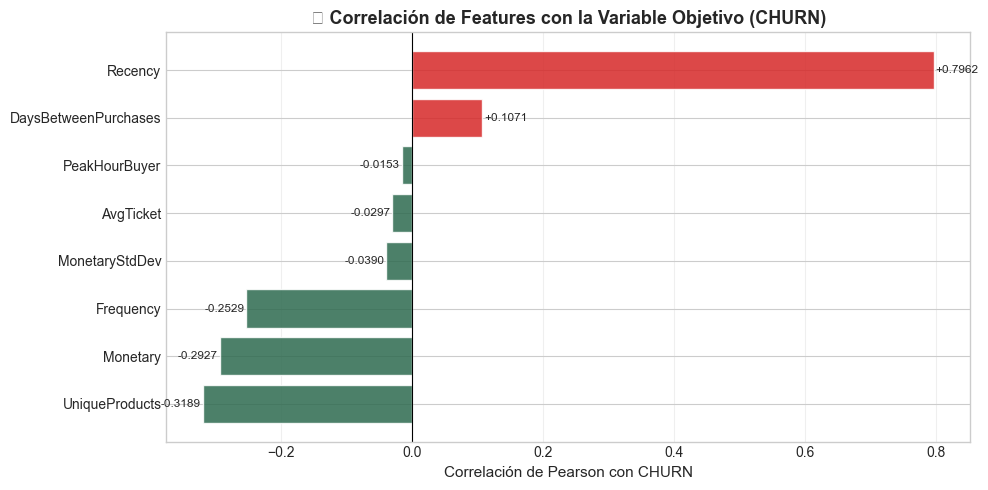


📌 Mayor correlación positiva  → Recency (+0.7962)
   Mayor correlación negativa  → UniqueProducts (-0.3189)


In [5]:
all_feat_cols = ['Recency','Frequency','Monetary'] + [f for f in available_adv if f in rfm_enriched.columns]
corr_churn = rfm_enriched[all_feat_cols + ['CHURN']].corr()['CHURN'].drop('CHURN').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [COLORS['danger'] if v > 0 else COLORS['primary'] for v in corr_churn.values]
bars = ax.barh(corr_churn.index, corr_churn.values, color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, corr_churn.values):
    ax.text(val + (0.003 if val >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8.5)
ax.set_xlabel('Correlación de Pearson con CHURN', fontsize=11)
ax.set_title('🎯 Correlación de Features con la Variable Objetivo (CHURN)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('reports/figures/eda/feature_churn_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

top_pos = corr_churn[corr_churn > 0].idxmax()
top_neg = corr_churn[corr_churn < 0].idxmin()
print(f'\n📌 Mayor correlación positiva  → {top_pos} ({corr_churn[top_pos]:+.4f})')
print(f'   Mayor correlación negativa  → {top_neg} ({corr_churn[top_neg]:+.4f})')

---
## 🔥 5. Matriz de Correlación — Detectar Multicolinealidad <a id='5'></a>

> Si dos features tienen correlación > 0.9 entre sí, uno de ellos puede ser redundante.  
> Los árboles de decisión (RF, XGBoost) son robustos a multicolinealidad; la Regresión Logística no.

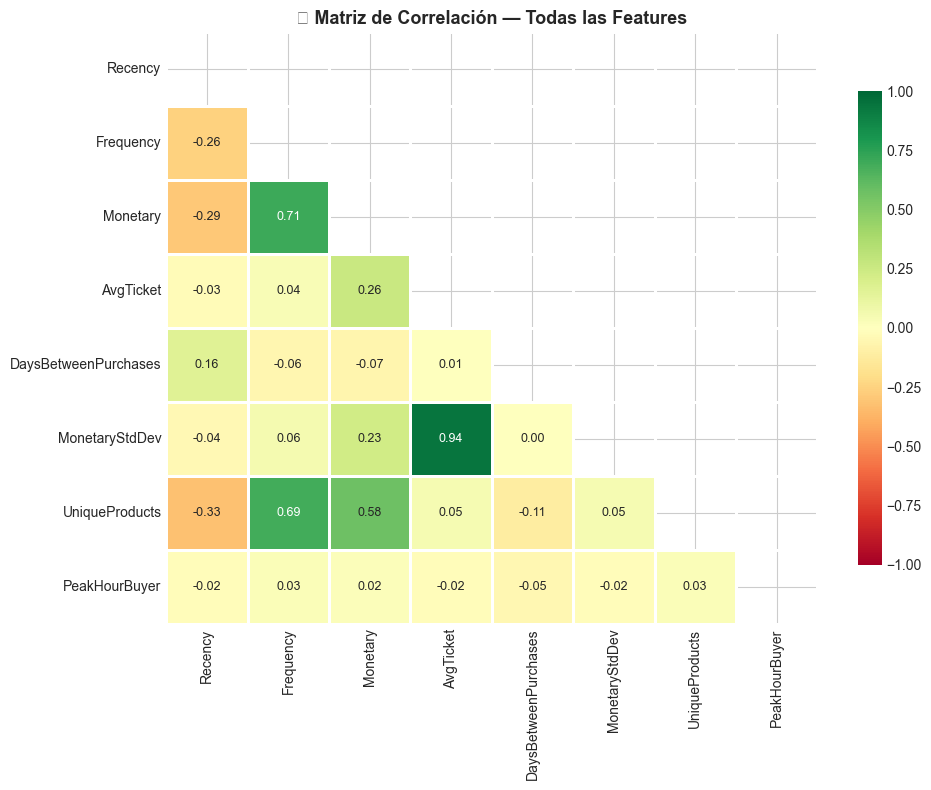

⚠️  Pares con correlación > |0.7|:
   AvgTicket ↔ MonetaryStdDev: 0.939
   Frequency ↔ Monetary: 0.709


In [6]:
corr_matrix = rfm_enriched[all_feat_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=1,
            cbar_kws={'shrink':0.8}, annot_kws={'size':9})
ax.set_title('🔥 Matriz de Correlación — Todas las Features', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/eda/full_feature_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Detectar pares de alta correlación
high_corr = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i,j]
        if abs(r) > 0.7:
            high_corr.append((corr_matrix.index[i], corr_matrix.columns[j], r))

if high_corr:
    print('⚠️  Pares con correlación > |0.7|:')
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'   {a} ↔ {b}: {r:.3f}')
else:
    print('✅ No hay multicolinealidad severa (|r| > 0.7) entre features.')

---
## ⚖️ 6. Escalamiento de Features <a id='6'></a>

> **¿Por qué escalar?**  
> Algoritmos como Logistic Regression y SVM son sensibles a la escala de las variables.  
> XGBoost y Random Forest son invariantes al escalamiento (pero escalamos igualmente para reproducibilidad).  

> **🔑 Importante:** El `FeatureScaler` serializa los parámetros del scaler (media y std) aprendidos en train.  
> En producción/inferencia, se carga el mismo scaler — nunca se re-ajusta.

In [7]:
from src.features.scaler import FeatureScaler

features_to_scale = [f for f in all_feat_cols if f in rfm_enriched.columns]
scaler = FeatureScaler(features=features_to_scale)
rfm_scaled = scaler.fit_transform(rfm_enriched)

scaler_path = 'models/champion/scaler.pkl'
Path('models/champion').mkdir(parents=True, exist_ok=True)
scaler.save(scaler_path)

print(f'✅ Scaler ajustado sobre {len(features_to_scale)} features')
print(f'   Guardado en: {scaler_path}')
print(f'\nEstadísticas post-escalamiento (media ≈ 0, std ≈ 1):')
rfm_scaled[features_to_scale].describe().round(3)

✅ Scaler ajustado sobre 8 features
   Guardado en: models/champion/scaler.pkl

Estadísticas post-escalamiento (media ≈ 0, std ≈ 1):


,Recency,Frequency,Monetary,AvgTicket,DaysBetweenPurchases,MonetaryStdDev,UniqueProducts,PeakHourBuyer
count,5878.000,5878.000,5878.000,5878.000,5878.000,5878.000,5878.000,5878.000
mean,-0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.957,-0.407,-0.542,-0.320,-0.199,-0.112,-0.695,-1.458
25%,-0.838,-0.407,-0.462,-0.173,-0.199,-0.112,-0.541,-0.879
50%,-0.503,-0.253,-0.335,-0.088,-0.168,-0.059,-0.318,0.044
75%,0.854,0.055,-0.011,0.024,-0.120,0.001,0.180,1.125
max,2.569,30.112,6.311,69.010,11.314,72.531,21.190,1.243


---
## ✅ 7. Guardar y Conclusiones <a id='7'></a>

In [8]:
# Guardar el dataset enriquecido con las features originales (sin escalar)
rfm_enriched.to_parquet('data/processed/rfm_with_churn.parquet', index=False)

print('╔══════════════════════════════════════════════════════╗')
print('║    ⚙️  INGENIERÍA DE FEATURES — RESUMEN             ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'  Features base (RFM)    : Recency, Frequency, Monetary')
print(f'  Features avanzadas     : {len(available_adv)} ({available_adv})')
print(f'  Total features         : {len(all_feat_cols)}')
print(f'  Clientes en el dataset : {len(rfm_enriched):,}')
print(f'  Scaler serializado     : models/champion/scaler.pkl')
print('╠══════════════════════════════════════════════════════╣')
print('  📁 Outputs:')
print('  • data/processed/rfm_with_churn.parquet (enriquecido)')
print('  • models/champion/scaler.pkl')
print('  • reports/figures/eda/ (3 gráficos nuevos)')
print('  → Siguiente: 04_modeling_experiments.ipynb')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║    ⚙️  INGENIERÍA DE FEATURES — RESUMEN             ║
╠══════════════════════════════════════════════════════╣
  Features base (RFM)    : Recency, Frequency, Monetary
  Features avanzadas     : 5 (['AvgTicket', 'DaysBetweenPurchases', 'MonetaryStdDev', 'UniqueProducts', 'PeakHourBuyer'])
  Total features         : 8
  Clientes en el dataset : 5,878
  Scaler serializado     : models/champion/scaler.pkl
╠══════════════════════════════════════════════════════╣
  📁 Outputs:
  • data/processed/rfm_with_churn.parquet (enriquecido)
  • models/champion/scaler.pkl
  • reports/figures/eda/ (3 gráficos nuevos)
  → Siguiente: 04_modeling_experiments.ipynb
╚══════════════════════════════════════════════════════╝


<div style="background: #f0f0ff; border-left: 5px solid #6a0dad; padding: 15px 20px; border-radius: 6px; margin-top: 20px;">
  <strong>✅ Feature Engineering completado.</strong> El dataset ahora contiene <strong>3 features base + 5 avanzadas</strong>, todas las distribuciones validadas y el scaler serializado.
  <br><br>Continúa en <strong>04_modeling_experiments.ipynb</strong> para entrenar y comparar los modelos predictivos.
</div>